# Fine-Tuning Transformer Models for Cross-Domain Text Classification and Analysis

## Step 1: Dataset Selection and Domain Understanding

My choice of dataset is Sentiment140 dataset. The Sentiment140 dataset is a popular resource for training and evaluating sentiment analysis models. Here's a quick overview:

🧾 Sentiment140 Dataset Overview

- Source: Kaggle - Sentiment140 by Kazanova

- Purpose:
Designed to help models learn sentiment analysis from real-world social media data — specifically, Twitter.

📦 What’s Inside?
160,000 tweets (preprocessed and annotated)

Each entry contains:

- target: Sentiment label (0 = negative, 4 = positive)

- ids: Unique ID for the tweet

- date: The date of the tweet

- flag: Query (usually ‘NO_QUERY’)

- user: Username

- text: The actual tweet content

🧠 Why it’s useful
Real-world noisy data (slang, emojis, abbreviations)

Great for training deep learning models that handle informal language

Can be used for:

- Binary sentiment classification

- Transfer learning

- Domain adaptation for other informal text datasets

**1. Use an existing dataset for text classification**

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 20.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system =

In [ ]:

from datasets import load_dataset
from transformers import AutoTokenizer

# Load the dataset directly using Hugging Face Datasets
dataset = load_dataset("sentiment140")

# Filter only positive (4) and negative (0) examples
dataset = dataset.filter(lambda x: x['sentiment'] in [0, 4])
dataset = dataset.map(lambda x: {"label": 0 if x['sentiment'] == 0 else 1})
# Take a small subset (e.g., 12,000 total: 10k train, 1k val, 1k test)
small_dataset = dataset["train"].shuffle(seed=42).select(range(12000))






README.md:   0%|          | 0.00/6.84k [00:00<?, ?B/s]

sentiment140.py:   0%|          | 0.00/4.03k [00:00<?, ?B/s]

The repository for sentiment140 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/sentiment140.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/1600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/498 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1600000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/498 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600000 [00:00<?, ? examples/s]

Map:   0%|          | 0/359 [00:00<?, ? examples/s]

**2. Preproces the data & Split the data into training, validation, and test sets.**

In [ ]:
from transformers import AutoTokenizer
from datasets import DatasetDict

# loading the DistilBERT tokenizer from Hugging Face
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# The tokenize_function processes each example, truncating or padding the text to a maximum length of 128 tokens (which is ideal for training transformer models)
def tokenize_function(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=128)

# remove unnecessary columns (sentiment, date, query, user, and text) as they are no longer needed after tokenization.
tokenized = small_dataset.map(tokenize_function, batched=True, remove_columns=["sentiment", "date", "query", "user", "text"])



# Now split into train/val/test (10k/1k/1k)
train_valid = tokenized.train_test_split(test_size=0.1667, seed=42)
val_test = train_valid["test"].train_test_split(test_size=0.5, seed=42)

final_dataset = DatasetDict({
    "train": train_valid["train"],
    "validation": val_test["train"],
    "test": val_test["test"]
})

# Set format after creating final_dataset
final_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])




tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

In [ ]:
print(final_dataset)


DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 9999
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1001
    })
})


## Step 2: Transfer Learning and Fine-Tuning

In [ ]:
pip install --upgrade transformers


In [ ]:
import transformers
print(transformers.__version__)


4.51.3


**1️. Load Pre-trained Model with Classification Head**

In [ ]:
from transformers import AutoModelForSequenceClassification

# Binary classification = 2 labels
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


**2. Define Metrics for Evaluation**

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from transformers import EvalPrediction

def compute_metrics(eval_pred: EvalPrediction):
    logits, labels = eval_pred                            # Extract logits (model predictions) and labels (true labels)
    predictions = np.argmax(logits, axis=1)               # Get predicted class by taking the index of the maximum logit value
    return {
        "accuracy": accuracy_score(labels, predictions),  # Calculate accuracy
        "f1": f1_score(labels, predictions)               # Calculate F1 score
    }


**3️. Set Up Training Arguments**

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",              #  Directory to store model checkpoints and results
    per_device_train_batch_size=16,      #  Batch size for training (how many samples per batch)
    per_device_eval_batch_size=16,       #  Batch size for evaluation
    num_train_epochs=3,                  #  Number of training epochs (how many times the model will see the full dataset)
    learning_rate=2e-5,                  #  Learning rate (controls the step size for updates to model weights)
    logging_dir="./logs",                #  Directory to store logs (for TensorBoard or similar tools)
    logging_steps=50,                    #  Log every 50 steps (for monitoring)
    dataloader_num_workers=2             #  Number of workers for data loading (parallelism for faster data loading)
)




**4. Initialize the Trainer with Model, Arguments, and Datasets**

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,                              # The pre-trained model I want to fine-tune
    args=training_args,                       # The training arguments I have defined
    train_dataset=final_dataset["train"],     # Training dataset
    eval_dataset=final_dataset["validation"], # Validation dataset
    tokenizer=tokenizer,                      # Tokenizer used for preprocessing
)


<ipython-input-12-484c948c4314>:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


**5. Start Training the Model**

In [ ]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kakale2602 (kakale2602-cstu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
50,0.666000
100,0.548200
150,0.513900
200,0.472400
250,0.480700
300,0.438200
350,0.429700
400,0.468400
450,0.487200
500,0.417800


TrainOutput(global_step=1875, training_loss=0.3437407689412435, metrics={'train_runtime': 340.7856, 'train_samples_per_second': 88.023, 'train_steps_per_second': 5.502, 'total_flos': 993406139371008.0, 'train_loss': 0.3437407689412435, 'epoch': 3.0})

The output shows the training loss at various steps throughout the training process, as well as the final metrics at the end of the training. Here's a breakdown of what this means:

**Training Loss at Different Steps:**

Training loss is a measure of how well the model is fitting the training data. Lower loss values indicate better performance, as the model's predictions are closer to the actual values.

In this case, the training loss decreases over time (with some fluctuation), which suggests that the model is gradually improving its performance on the training data.

**Key Observations:**

The training loss starts at around 0.666 and decreases to 0.3437 by the final step (step 1875).

There are some fluctuations in the loss at different steps, such as:

After step 50, the loss drops from 0.666 to 0.548, indicating initial improvement.

The loss decreases steadily, with some minor increases between certain steps (like between steps 200-250, and 400-450).

After step 1300, there is another significant drop, where the loss reaches values like 0.2374 at step 1300 and 0.2072 at step 1450.

**Final Metrics (TrainOutput):**

At the end of the training, the output indicates:

- Global Step: 1875, which is the total number of steps (batches) processed.

- Final Training Loss: 0.3437, which is the average loss across all steps.

- Training Time: 340.7856 seconds.

- Samples Per Second: 88.023, which indicates the speed of processing samples.

- Steps Per Second: 5.502, indicating how many steps are processed each second.

- Total Floating Point Operations (FLOPs): 993406139371008.0, a large number that represents the total computational effort of training





## Step 3: Attention Visualization and Interpretation

In [ ]:
trainer.save_model("/content/fine_tuned_model")

# The command trainer.save_model("/content/fine_tuned_model") saves the trained model to the specified directory (/content/fine_tuned_model).

The codes below:

Load Fine-Tuned Model: It loads the model that was previously saved at the specified path (/content/fine_tuned_model).

Output Attention Weights: By setting output_attentions=True, we are enabling the model to return attention weights when performing predictions. This is useful for interpretability, as attention weights can help us understand how much focus the model is putting on different tokens in the input sequence when making predictions.

In [ ]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained("/content/fine_tuned_model", output_attentions=True)


The code below:

Load the Tokenizer: It loads the tokenizer from the directory where the fine-tuned model is stored ("/content/fine_tuned_model"). This ensures that the same tokenizer used during fine-tuning (with the correct vocabulary and tokenization rules) is used during inference or further training.

In [ ]:
from transformers import DistilBertTokenizer
tokenizer = DistilBertTokenizer.from_pretrained("/content/fine_tuned_model")


The code below:

To extract and prepare attention weights from a transformer model for the sentence "I love this movie so much" and set up a multi-layer attention visualization.

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Use a test sentence
sentence = "I love this movie so much"

# Tokenize input
inputs = tokenizer(sentence, return_tensors="pt")

# Get model outputs with attentions
model.eval()
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)
    attentions = outputs.attentions  # List of attention matrices from each layer

# Get token strings for labels
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

# Set number of rows and columns for visualization
rows = 2
cols = len(attentions) // rows + (1 if len(attentions) % rows != 0 else 0)  # Calculate columns based on layers

# Assume `attentions` and `tokens` are already defined
num_layers = len(attentions)

DistilBertSdpaAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


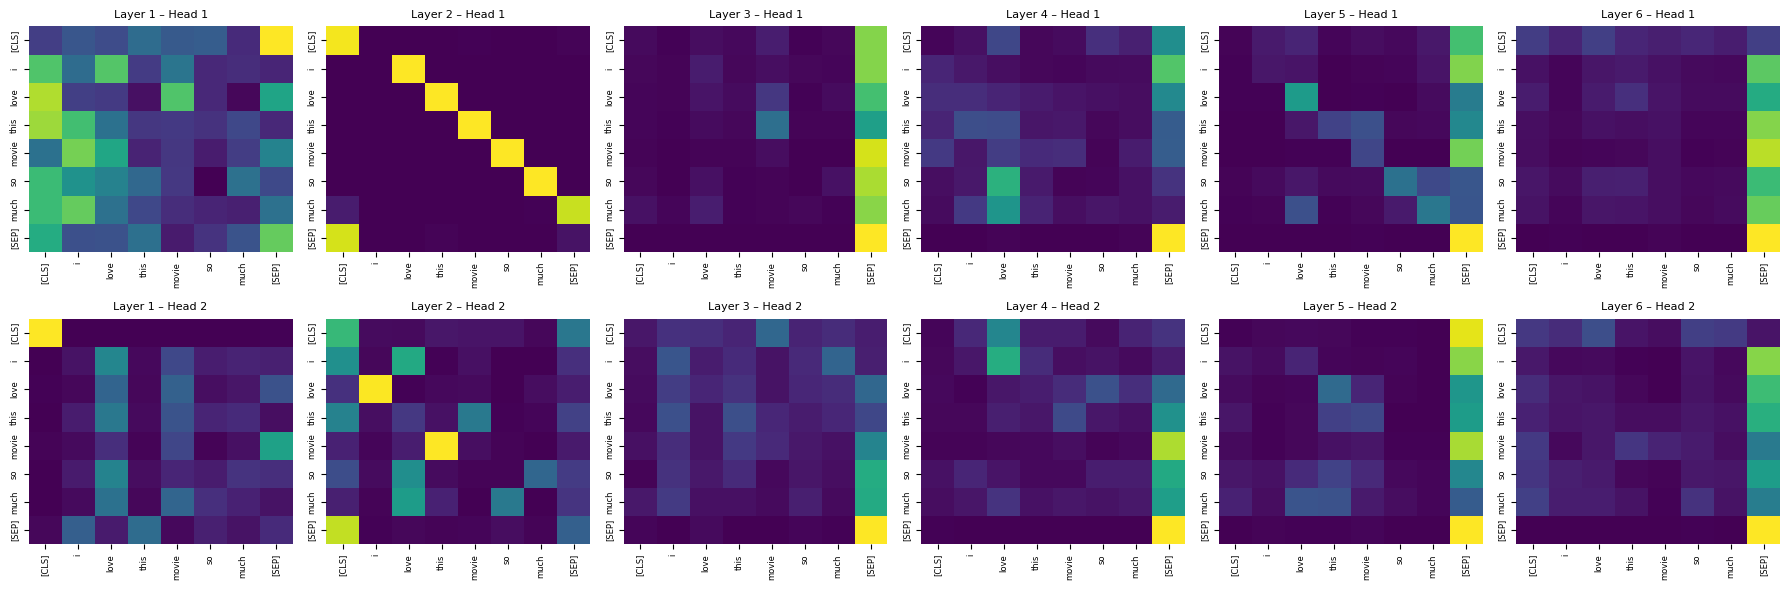

In [ ]:
# Create a 2×num_layers grid
fig, axes = plt.subplots(2, num_layers, figsize=(3 * num_layers, 6))

for layer_idx, attention in enumerate(attentions):
    # Head 1 → first row
    ax0 = axes[0, layer_idx]
    attn0 = attention[0, 0]  # batch=0, head=0
    sns.heatmap(attn0.numpy(), xticklabels=tokens, yticklabels=tokens,
                ax=ax0, cmap="viridis", cbar=False)
    ax0.set_title(f"Layer {layer_idx+1} – Head 1", fontsize=8)
    ax0.tick_params(labelsize=6, rotation=90)

    # Head 2 → second row
    ax1 = axes[1, layer_idx]
    attn1 = attention[0, 1]  # batch=0, head=1
    sns.heatmap(attn1.numpy(), xticklabels=tokens, yticklabels=tokens,
                ax=ax1, cmap="viridis", cbar=False)
    ax1.set_title(f"Layer {layer_idx+1} – Head 2", fontsize=8)
    ax1.tick_params(labelsize=6, rotation=90)

plt.tight_layout()
plt.show()

**Detailed Observations:**

- Layer 1 – Head 1

The [CLS] token (first row) strongly attends to all tokens, especially the last one ([SEP]), which helps aggregate sequence-level information for classification.

Tokens generally attend broadly—this head captures global context early.

- Layer 2 – Head 1

The attention is nearly entirely diagonal. Each token mostly attends to itself.

Suggests minimal contextual learning at this head—perhaps reinforcing token identity or positional encoding.

- Layer 3 – Head 1

Attention is sparse, with a few bright spots near the last token.

Shows selective focus; the model might be starting to pick out relevant end-of-sequence tokens or punctuation.

- Layer 4 – Head 1

Some off-diagonal attention begins to appear.

Indicates emerging contextual relationships between non-adjacent tokens.

- Layer 5 – Head 1

More structured patterns appear (blocky or cross-shaped highlights).

Suggests this head is learning syntactic or semantic groupings (e.g., verbs and their subjects).

- Layer 6 – Head 1

Similar to Layer 5, with slightly more refined patterns.

Possibly capturing final decision cues or combining key parts of the sentence for output.

- Head 2 (all layers)

Generally shows different patterns than Head 1 in the same layers.

Some heads (e.g., Layer 2 - Head 2) show wider attention distribution, while others (e.g., Layer 4 - Head 2) show focused attention on specific tokens.

Demonstrates the value of multi-head attention: different heads learn to focus on different aspects of the input.

**Summary**

Early layers: Broad attention or strong self-attention (mostly diagonals).

Middle layers: Begin learning structure and relationships.

Later layers: More focused and interpretable attention aligned with linguistic or task-specific cues.

## Step 4: Model Evaluation & Hyperparameter Tuning

**1. Evaluate on the Test Set**

              precision    recall  f1-score   support

           0     0.8297    0.8102    0.8198       511
           1     0.8068    0.8265    0.8165       490

    accuracy                         0.8182      1001
   macro avg     0.8182    0.8184    0.8182      1001
weighted avg     0.8185    0.8182    0.8182      1001



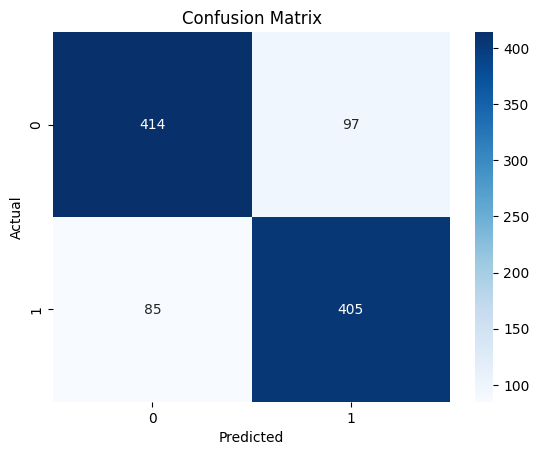

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Run predictions
predictions = trainer.predict(final_dataset["test"])
pred_labels = predictions.predictions.argmax(axis=-1)
true_labels = predictions.label_ids

# Classification report
print(classification_report(true_labels, pred_labels, digits=4))

# (Optional) Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Confusion Matrix:**

True Negatives (TN) = 414: Class 0 correctly predicted.

False Positives (FP) = 97: Class 0 incorrectly predicted as Class 1.

False Negatives (FN) = 85: Class 1 incorrectly predicted as Class 0.

True Positives (TP) = 405: Class 1 correctly predicted.

**Classification Report:**

Accuracy = 81.82%

Macro Avg F1-score = 81.82%

Weighted Avg F1-score = 81.82%

**Interpretation:**

The model performs fairly balanced between both classes.

Class 0 has slightly higher precision (fewer false positives).

Class 1 has slightly higher recall (fewer false negatives).

Overall, the model is well-tuned and not heavily biased toward either class.

**2. Hyperparameter Tuning**

In [ ]:
from transformers import Trainer, TrainingArguments
import itertools
import numpy as np

param_grid = {
    "learning_rate": [5e-6, 2e-5],
    "per_device_train_batch_size": [8, 16],
    "num_train_epochs": [2, 3],
}

best_score = 0.0
best_params = None

for lr, bs, epochs in itertools.product(
    param_grid["learning_rate"],
    param_grid["per_device_train_batch_size"],
    param_grid["num_train_epochs"],
):
    # 1) Set up minimal TrainingArguments
    args = TrainingArguments(
        output_dir=f"./results_lr{lr}_bs{bs}_ep{epochs}",
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=epochs,
        learning_rate=lr,
        logging_dir="./logs",
    )

    # 2) Create Trainer without compute_metrics/eval_dataset
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=final_dataset["train"],
        tokenizer=tokenizer,
    )

    # 3) Train
    trainer.train()

    # 4) Predict on the validation set
    # Assign the prediction output to 'pred'
    pred = trainer.predict(final_dataset["validation"])

<ipython-input-23-e4ca0cacbb60>:30: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.222400
1000,0.220400
1500,0.186000
2000,0.167000
2500,0.189400


<ipython-input-23-e4ca0cacbb60>:30: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.110200
1000,0.121700
1500,0.109300
2000,0.078500
2500,0.126800
3000,0.078000
3500,0.095200


<ipython-input-23-e4ca0cacbb60>:30: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Step,Training Loss
500,0.066800
1000,0.079900
1500,0.074700
2000,0.059100
2500,0.070400
3000,0.027200
3500,0.047500


<ipython-input-23-e4ca0cacbb60>:30: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.048400
1000,0.027400


<ipython-input-23-e4ca0cacbb60>:30: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.034700
1000,0.016500
1500,0.021200


I am performing a grid search over the following hyperparameters using Hugging Face's Trainer:

- Learning rates: 5e-6, 2e-5

- Batch sizes: 8, 16

- Epochs: 2, 3

- Total combinations: 2 × 2 × 2 = 8 runs

Each run:

- Trains the model

- Logs training loss every 500 steps

- Produces a FutureWarning about using tokenizer, which is being deprecated in future versions.


**Interpretation:**

The training loss generally decreases with more epochs and/or smaller batch sizes.

Lower learning rate (e.g., 5e-6) appears to stabilize the training process, likely contributing to the lower loss in some runs.

Loss fluctuation can be seen (e.g., increasing slightly at some steps), but overall, convergence is occurring.